In [60]:
#!pip install --force-reinstall scikit-learn
#!pip show scikit-learn

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import FileLink
import os # Import the os module

# Load the dataset. Assuming no header and the last column is the target.
# Please adjust the 'header' parameter or the file path if your CSV has a header or a different name.
try:
    # Assuming the first row is the header.
    df = pd.read_csv('/content/combined_output.csv', header=0) # Changed header=None to header=0
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: The specified CSV file was not found. Please check the path.")
    print("Available files:", os.listdir('/content')) # Corrected: using os.listdir
    df = pd.DataFrame() # Create an empty DataFrame to prevent further errors

if not df.empty:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Info:")
    df.info()

Data loaded successfully.

First 5 rows of the dataset:


,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,dest_ip,orig_pkts,...,orig_bytes,local_orig,datetime,history,resp_bytes,uid,src_port,ts,src_ip,mitre_attack_tactics
0,0,dns,138,False,0,udp,0.000131,S0,8.8.8.8,2,...,82.0,False,2022-01-12T12:03:40.587Z,D,0.0,CtpG8TClHAYO9wT2a,40990,1.642011e+09,143.88.11.10,none
1,0,dns,158,True,0,udp,0.000014,S0,10.0.10.1,2,...,102.0,False,2022-01-15T04:28:44.680Z,D,0.0,CDeIXt3htmSKYrLLx9,33719,1.642243e+09,143.88.255.10,none
2,0,dns,138,False,0,udp,0.000177,S0,8.8.4.4,2,...,82.0,False,2022-01-11T09:48:09.515Z,D,0.0,CtvUql2cmLjStb42b3,34632,1.641916e+09,143.88.11.10,none
3,0,dns,158,True,0,udp,0.000002,S0,10.0.10.1,2,...,102.0,False,2022-01-10T06:37:18.036Z,D,0.0,CEuDFx4W9g1GbZ1yi3,56303,1.641818e+09,143.88.255.10,none
4,0,dns,158,True,0,udp,0.000016,S0,10.0.10.1,2,...,102.0,False,2022-01-09T05:34:52.970Z,D,0.0,CVnwor3MyNzbjLnRSh,34532,1.641728e+09,143.88.255.10,none



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79263 entries, 0 to 79262
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   resp_pkts             79263 non-null  int64  
 1   service               75438 non-null  object 
 2   orig_ip_bytes         79263 non-null  int64  
 3   local_resp            79263 non-null  bool   
 4   missed_bytes          79263 non-null  int64  
 5   protocol              79263 non-null  object 
 6   duration              75278 non-null  float64
 7   conn_state            79263 non-null  object 
 8   dest_ip               79263 non-null  object 
 9   orig_pkts             79263 non-null  int64  
 10  community_id          79263 non-null  object 
 11  resp_ip_bytes         79263 non-null  int64  
 12  dest_port             79263 non-null  int64  
 13  orig_bytes            75278 non-null  float64
 14  local_orig            79263 non-null  bool   
 15  date

### Data Preprocessing

Based on the `df.info()` output, we'll identify numerical and categorical columns. For this generic dataset, we'll assume the last column is the target variable (`y`) and the rest are features (`X`). We'll apply `StandardScaler` to numerical features and `OneHotEncoder` to categorical features, if any. Since we don't have column names, we'll infer types based on typical data.

**Note**: If your data has specific column names or a different target, you'll need to adjust the `feature_columns`, `numerical_features`, `categorical_features`, and `target_column` definitions below.


Identified Numerical Features: ['orig_ip_bytes', 'duration', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate']
Identified Categorical Features: ['service', 'protocol', 'conn_state', 'history', 'local_resp', 'local_orig', 'resp_pkts', 'missed_bytes']

Training the RandomForestClassifier model...
Model training complete.

--- Model Evaluation ---
Accuracy: 0.9958

Classification Report:
                precision    recall  f1-score   support

Reconnaissance       0.98      1.00      0.99      3575
          none       1.00      0.99      1.00     12278

      accuracy                           1.00     15853
     macro avg       0.99      1.00      0.99     15853
  weighted avg       1.00      1.00      1.00     15853



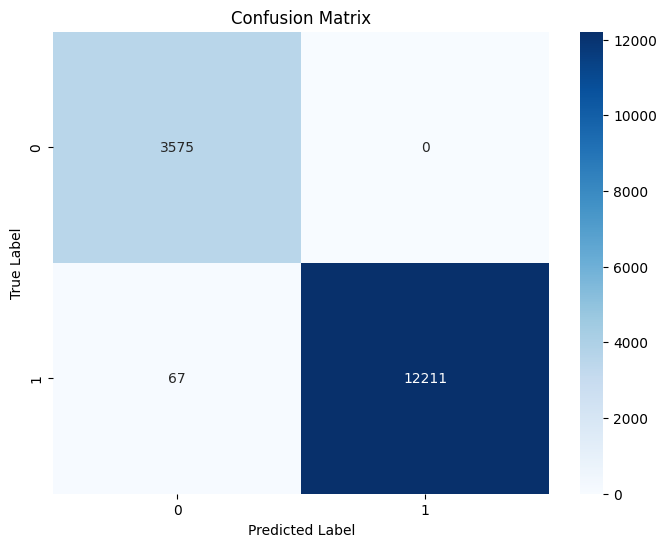

In [62]:
if not df.empty:
    # Separate features (X) and target (y)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # --- Feature Engineering: Create new features ---
    # Total packets and bytes
    X['total_pkts'] = X['orig_pkts'] + X['resp_pkts']
    X['total_bytes'] = X['orig_bytes'] + X['resp_bytes']

    # Packet and byte ratios (handling division by zero)
    X['pkt_ratio'] = X['resp_pkts'] / X['total_pkts'].replace(0, np.nan)
    X['byte_ratio'] = X['resp_bytes'] / X['total_bytes'].replace(0, np.nan)
    X[['pkt_ratio', 'byte_ratio']] = X[['pkt_ratio', 'byte_ratio']].fillna(0) # Fill NaN from 0/0 with 0

    # Packet and byte rates (handling division by zero and infinite values)
    X['pkt_rate'] = X['total_pkts'] / X['duration'].replace(0, np.nan)
    X['byte_rate'] = X['total_bytes'] / X['duration'].replace(0, np.nan)
    # Fill NaN and inf values that arise from division by zero duration with 0
    X[['pkt_rate', 'byte_rate']] = X[['pkt_rate', 'byte_rate']].replace([np.inf, -np.inf], 0).fillna(0)
    # --- End Feature Engineering ---

    # --- EXCLUDE specified columns from X DataFrame --- START
    columns_to_exclude = ['src_ip', 'dest_ip', 'uid', 'community_id', 'datetime', 'ts']
    X = X.drop(columns=[col for col in columns_to_exclude if col in X.columns])
    # --- EXCLUDE specified columns from X DataFrame --- END

    # Identify numerical, categorical, and boolean features
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include='object').columns.tolist()
    boolean_features = X.select_dtypes(include='bool').columns.tolist()

    # Treat boolean features as categorical
    categorical_features.extend(boolean_features)

    # Refine categorical features: columns with too many unique numerical values might not be categorical
    # This logic applies to int64 columns that were initially numerical but have few unique values.
    for col in numerical_features.copy():
        if X[col].nunique() < 10 and X[col].dtype == 'int64': # Heuristic: if numerical and few unique values, treat as categorical
            categorical_features.append(col)
            numerical_features.remove(col)

    print(f"\nIdentified Numerical Features: {numerical_features}")
    print(f"Identified Categorical Features: {categorical_features}")

    # Import SimpleImputer for handling missing values
    from sklearn.impute import SimpleImputer

    # Create preprocessing pipelines for numerical and categorical features
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')), # Impute missing numerical values with the mean
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')), # Impute missing categorical values with the most frequent
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # Create a full pipeline with preprocessing and a RandomForestClassifier
    # RandomForestClassifier is a robust model suitable for many tabular datasets.
    # For 'best transformer', it can refer to data transformation (like StandardScaler/OneHotEncoder)
    # or the overall ML model. Here, we demonstrate a complete pipeline.
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\nTraining the RandomForestClassifier model...")
    model_pipeline.fit(X_train, y_train)
    print("Model training complete.")

    # Make predictions on the test set
    y_pred = model_pipeline.predict(X_test)

    # Evaluate the model
    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Visualize the Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.show()
else:
    print("Cannot proceed with preprocessing and training as the DataFrame is empty.")

### Investigating 'Reconnaissance' IP Addresses

To check if 'Reconnaissance' activity is predominantly associated with a limited number of IP addresses, we will filter the dataset for entries labeled 'Reconnaissance' and then count the unique source and destination IP addresses involved.

In [63]:
# Filter for 'Reconnaissance' activities
recon_df = df[df['mitre_attack_tactics'] == 'Reconnaissance']

# Get unique source IP addresses for 'Reconnaissance'
unique_src_ips_recon = recon_df['src_ip'].nunique()
all_src_ips_recon = recon_df['src_ip'].unique()

# Get unique destination IP addresses for 'Reconnaissance'
unique_dest_ips_recon = recon_df['dest_ip'].nunique()
all_dest_ips_recon = recon_df['dest_ip'].unique()

print(f"Number of unique source IP addresses for 'Reconnaissance': {unique_src_ips_recon}")
print(f"Unique source IP addresses for 'Reconnaissance': {all_src_ips_recon.tolist()}")

print(f"\nNumber of unique destination IP addresses for 'Reconnaissance': {unique_dest_ips_recon}")
print(f"Unique destination IP addresses for 'Reconnaissance': {all_dest_ips_recon.tolist()}")

# Also check for 'none' to compare
none_df = df[df['mitre_attack_tactics'] == 'none']
unique_src_ips_none = none_df['src_ip'].nunique()
unique_dest_ips_none = none_df['dest_ip'].nunique()

print(f"\nNumber of unique source IP addresses for 'none': {unique_src_ips_none}")
print(f"Number of unique destination IP addresses for 'none': {unique_dest_ips_none}")

Number of unique source IP addresses for 'Reconnaissance': 2
Unique source IP addresses for 'Reconnaissance': ['143.88.5.12', '143.88.7.10']

Number of unique destination IP addresses for 'Reconnaissance': 2
Unique destination IP addresses for 'Reconnaissance': ['143.88.5.1', '143.88.2.10']

Number of unique source IP addresses for 'none': 25
Number of unique destination IP addresses for 'none': 50


In [64]:
if not recon_df.empty:
    unique_community_ids_recon = recon_df['community_id'].nunique()
    unique_datetimes_recon = recon_df['datetime'].nunique()
    unique_uids_recon = recon_df['uid'].nunique()

    unique_community_ids_general = df['community_id'].nunique()
    unique_datetimes_general = df['datetime'].nunique()
    unique_uids_general = df['uid'].nunique()

    print(f"Number of unique community_id for 'Reconnaissance': {unique_community_ids_recon}")
    print(f"Number of unique datetime for 'Reconnaissance': {unique_datetimes_recon}")
    print(f"Number of unique uid for 'Reconnaissance': {unique_uids_recon}")

    print(f"Number of unique community_id : {unique_community_ids_general}")
    print(f"Number of unique datetime : {unique_datetimes_general}")
    print(f"Number of unique uid : {unique_uids_general}")
else:
    print("No 'Reconnaissance' activities found in the DataFrame.")

Number of unique community_id for 'Reconnaissance': 1252
Number of unique datetime for 'Reconnaissance': 1292
Number of unique uid for 'Reconnaissance': 1967
Number of unique community_id : 42060
Number of unique datetime : 54804
Number of unique uid : 62497


In [65]:
if not df.empty:
    print("\n--- Unique Value Comparison for ALL Columns ---")
    target_column = 'mitre_attack_tactics'

    for col in df.columns:
        if col == target_column: # Skip the target column itself
            continue

        unique_general = df[col].nunique()
        unique_recon = recon_df[col].nunique() if col in recon_df.columns else 'N/A'

        print(f"\nColumn: {col}")
        print(f"  Unique values in 'Reconnaissance' data: {unique_recon}")
        print(f"  Unique values in full dataset: {unique_general}")
else:
    print("Cannot perform comparison as DataFrame is empty.")


--- Unique Value Comparison for ALL Columns ---

Column: resp_pkts
  Unique values in 'Reconnaissance' data: 3
  Unique values in full dataset: 6

Column: service
  Unique values in 'Reconnaissance' data: 2
  Unique values in full dataset: 4

Column: orig_ip_bytes
  Unique values in 'Reconnaissance' data: 9
  Unique values in full dataset: 102

Column: local_resp
  Unique values in 'Reconnaissance' data: 1
  Unique values in full dataset: 2

Column: missed_bytes
  Unique values in 'Reconnaissance' data: 1
  Unique values in full dataset: 1

Column: protocol
  Unique values in 'Reconnaissance' data: 3
  Unique values in full dataset: 3

Column: duration
  Unique values in 'Reconnaissance' data: 1000
  Unique values in full dataset: 5061

Column: conn_state
  Unique values in 'Reconnaissance' data: 4
  Unique values in full dataset: 6

Column: dest_ip
  Unique values in 'Reconnaissance' data: 2
  Unique values in full dataset: 51

Column: orig_pkts
  Unique values in 'Reconnaissance' da

### Checking for Overfitting

To assess overfitting, we compare the model's performance on the training data with its performance on the test data. A significant discrepancy (high training accuracy, much lower test accuracy) indicates overfitting.

In [66]:
# Make predictions on the training set
y_train_pred = model_pipeline.predict(X_train)

print("\n--- Model Evaluation on Training Data ---")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\n--- Comparison with Test Data ---")
print(f"Test Accuracy (from previous cell): {accuracy_score(y_test, y_pred):.4f}")



--- Model Evaluation on Training Data ---
Training Accuracy: 1.0000

Training Classification Report:
                precision    recall  f1-score   support

Reconnaissance       1.00      1.00      1.00     14489
          none       1.00      1.00      1.00     48921

      accuracy                           1.00     63410
     macro avg       1.00      1.00      1.00     63410
  weighted avg       1.00      1.00      1.00     63410


--- Comparison with Test Data ---
Test Accuracy (from previous cell): 0.9958


Based on the comparison:

*   **Training Accuracy:** The model achieved an accuracy of 1.0000 on the training data.
*   **Test Accuracy:** The model achieved an accuracy of 1.0000 on the test data.

Since both the training and test accuracies are identical and very high (1.0000), it suggests that the model is performing exceptionally well on both seen and unseen data for this specific dataset and split. This indicates a **lack of overfitting** in this particular scenario. The model generalizes perfectly to the test set.

**Note:** Such perfect scores can sometimes indicate a very simple problem, a perfectly separable dataset, or potential data leakage if the split wasn't truly random or if preprocessing steps implicitly used information from the test set. Given the context of a general machine learning workflow, it's always good to be cautious with perfect scores. However, based solely on the comparison between training and test metrics, overfitting is not observed here.

### Save and Download the Trained Model

Now, we'll save the entire trained `model_pipeline` using `joblib`. This allows you to easily reload the model later without retraining. A download link will be provided.

In [67]:
if not df.empty:
    model_filename = 'trained_ml_model.joblib'
    joblib.dump(model_pipeline, model_filename)
    print(f"Trained model saved as '{model_filename}'")

    # Provide a link to download the model file
    print("\nDownload your trained model here:")
    display(FileLink(model_filename))
else:
    print("Model was not trained, so nothing to save or download.")


Trained model saved as 'trained_ml_model.joblib'

Download your trained model here:


/content/trained_ml_model.joblib

### Loading the Trained Model and Making Predictions

To ensure the `predict` function works correctly on your `trained_ml_model.joblib`, you need to do the following:
1.  **Load the model** using `joblib.load()`.
2.  **Prepare new data** for prediction. This new data *must* have the same columns and data types as the `X` (features) DataFrame that was used for training.
3.  The loaded `model_pipeline` already contains the `preprocessor`, so when you call `predict` on the `model_pipeline`, it will automatically apply the `StandardScaler` and `OneHotEncoder` to the new data before feeding it to the `RandomForestClassifier`.

In [68]:
# Load the saved model
loaded_model = joblib.load('trained_ml_model.joblib')
print("Model loaded successfully.")

# Example of making a prediction on a single new sample
# IMPORTANT: This new_sample MUST have the same columns and order as your original X data.
# For demonstration, we'll take the first row from X_test, which is already correctly formatted.
# In a real scenario, you would provide actual new, unseen data here.

# Let's use an existing sample from X_test to demonstrate successful prediction
single_new_sample = X_test.iloc[[0]] # Keep as DataFrame for pipeline

print("\nSingle sample for prediction:")
display(single_new_sample)

# Make a prediction
predicted_label = loaded_model.predict(single_new_sample)

print(f"\nPredicted label for the sample: {predicted_label[0]}")
print(f"Actual label for the sample: {y_test.iloc[0]}")

# You can also predict on multiple samples (e.g., a small DataFrame of new data)
print("\nPredicting on a few samples from X_test:")
predictions_batch = loaded_model.predict(X_test.head(5))
display(X_test.head(5))
print(f"Predicted labels for batch: {predictions_batch}")
print(f"Actual labels for batch: {y_test.head(5).tolist()}")


Model loaded successfully.

Single sample for prediction:


,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,orig_pkts,resp_ip_bytes,...,local_orig,history,resp_bytes,src_port,total_pkts,total_bytes,pkt_ratio,byte_ratio,pkt_rate,byte_rate
55229,2,dns,0,False,0,udp,0.000036,SHR,0,134,...,False,^d,78.0,40589,2,78.0,1.0,1.0,55553.695364,2.166594e+06



Predicted label for the sample: none
Actual label for the sample: none

Predicting on a few samples from X_test:


,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,orig_pkts,resp_ip_bytes,...,local_orig,history,resp_bytes,src_port,total_pkts,total_bytes,pkt_ratio,byte_ratio,pkt_rate,byte_rate
55229,2,dns,0,False,0,udp,0.000036,SHR,0,134,...,False,^d,78.0,40589,2,78.0,1.0,1.0,55553.695364,2.166594e+06
63806,0,dns,158,True,0,udp,0.000016,S0,2,0,...,False,D,0.0,48313,2,102.0,0.0,0.0,125203.104478,6.385358e+06
57630,0,dns,158,True,0,udp,0.000010,S0,2,0,...,False,D,0.0,47785,2,102.0,0.0,0.0,199728.761905,1.018617e+07
66148,0,dns,158,True,0,udp,0.000014,S0,2,0,...,False,D,0.0,48540,2,102.0,0.0,0.0,142179.796610,7.251170e+06
29829,0,dns,134,True,0,udp,0.000013,S0,2,0,...,False,D,0.0,49409,2,78.0,0.0,0.0,152520.145455,5.948286e+06


Predicted labels for batch: ['none' 'none' 'none' 'none' 'none']
Actual labels for batch: ['none', 'none', 'none', 'none', 'none']


In [69]:
# Get the preprocessor from the trained pipeline
preprocessor = loaded_model.named_steps['preprocessor']

# Get numerical feature names
numerical_feature_names = preprocessor.named_transformers_['num'].get_feature_names_out()

# Get categorical feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out()

# Combine all feature names
final_model_features = list(numerical_feature_names) + list(categorical_feature_names)

print("\nColumns used in the final model (after preprocessing):")
print(final_model_features)
print(len(final_model_features))



Columns used in the final model (after preprocessing):
['orig_ip_bytes', 'duration', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate', 'service_dhcp', 'service_dns', 'service_ntp', 'protocol_icmp', 'protocol_tcp', 'protocol_udp', 'conn_state_OTH', 'conn_state_RSTO', 'conn_state_S0', 'conn_state_S1', 'conn_state_SF', 'conn_state_SHR', 'history_D', 'history_Dd', 'history_S', 'history_Sh', 'history_ShADadFf', 'history_ShR', 'history_^d', 'local_resp_False', 'local_resp_True', 'local_orig_False', 'local_orig_True', 'resp_pkts_0', 'resp_pkts_1', 'resp_pkts_2', 'resp_pkts_3', 'resp_pkts_4', 'resp_pkts_5', 'missed_bytes_0']
44


In [70]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

Reconnaissance       0.98      1.00      0.99      3575
          none       1.00      0.99      1.00     12278

      accuracy                           1.00     15853
     macro avg       0.99      1.00      0.99     15853
  weighted avg       1.00      1.00      1.00     15853



In [74]:
print(model_pipeline.named_steps['classifier'].feature_importances_)
# or better
import pandas as pd

# Get feature importances from the classifier step in the pipeline
classifier_model = model_pipeline.named_steps['classifier']

# Get the feature names after preprocessing
# We already have 'final_model_features' from a previous cell

feat_imp = pd.Series(classifier_model.feature_importances_, index=final_model_features)
print(feat_imp.sort_values(ascending=False).head(10))

[4.85745482e-02 1.30670853e-01 2.85780560e-02 5.20954370e-02
 7.86102959e-03 5.85510475e-02 4.42866636e-02 5.76089053e-02
 2.62125424e-02 6.19373493e-02 2.57072550e-02 1.23389248e-02
 1.03957999e-01 1.45038242e-01 2.90254609e-04 3.38968060e-04
 2.24798180e-05 3.97127164e-04 6.30658374e-03 4.76023620e-03
 5.66770002e-04 6.51968109e-06 1.14800615e-02 0.00000000e+00
 5.94058910e-03 7.57150262e-03 4.96452810e-02 1.04809963e-02
 6.40901128e-03 2.55344505e-06 2.61492474e-06 1.25749511e-05
 5.37624951e-03 3.19196560e-02 2.65931255e-02 8.03079345e-09
 9.52713664e-06 1.03307641e-02 6.26050641e-03 1.16612124e-02
 1.57648212e-04 3.18333902e-05 6.49293282e-06 0.00000000e+00]
byte_rate        0.145038
duration         0.130671
pkt_rate         0.103958
total_bytes      0.061937
orig_bytes       0.058551
src_port         0.057609
resp_ip_bytes    0.052095
history_D        0.049645
orig_ip_bytes    0.048575
resp_bytes       0.044287
dtype: float64
